# Import Dataset

In [ ]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt

#Import dan Load Dataset
print("Silakan upload file dataset CSV (ulasan_plnmobile.csv)")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name, encoding="utf-8")

print("Dataset berhasil dimuat")

Silakan upload file dataset CSV (ulasan_plnmobile.csv)


Saving ulasan_plnmobile.csv to ulasan_plnmobile.csv
Dataset berhasil dimuat


# Pemeriksaan Struktur Data

In [ ]:
# Menampilkan 5 data pertama
df.head()

# Jumlah baris dan kolom
print("Jumlah baris:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

# Informasi tipe data
df.info()

Jumlah baris: 20489
Jumlah kolom: 5
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20489 entries, 0 to 20488
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   nama     20489 non-null  object 
 1   rating   20489 non-null  float64
 2   ulasan   20489 non-null  object 
 3   tanggal  20489 non-null  object 
 4   sumber   20489 non-null  object 
dtypes: float64(1), object(4)
memory usage: 800.5+ KB


# Analisis Deskriptif Dataset

In [ ]:
print(" ANALISIS DESKRIPTIF DATASET")

# Jumlah baris dan kolom
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}\n")

# Informasi tipe data
print(" Informasi Tipe Data:")
df.info()

# Ringkasan deskriptif kolom
print("\n📋 Ringkasan Deskriptif per Kolom:")
deskriptif = pd.DataFrame({
    "Kolom": df.columns,
    "Tipe Data": df.dtypes.astype(str),
    "Count": df.count(),
    "Unique": df.nunique(),
    "Missing Values": df.isnull().sum()
})

deskriptif


 ANALISIS DESKRIPTIF DATASET
Jumlah baris: 20489
Jumlah kolom: 5

 Informasi Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20489 entries, 0 to 20488
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   nama     20489 non-null  object 
 1   rating   20489 non-null  float64
 2   ulasan   20489 non-null  object 
 3   tanggal  20489 non-null  object 
 4   sumber   20489 non-null  object 
dtypes: float64(1), object(4)
memory usage: 800.5+ KB

📋 Ringkasan Deskriptif per Kolom:


,Kolom,Tipe Data,Count,Unique,Missing Values
nama,nama,object,20489,20112,0
rating,rating,float64,20489,5,0
ulasan,ulasan,object,20489,16744,0
tanggal,tanggal,object,20489,20286,0
sumber,sumber,object,20489,2,0


# Distribusi Sumber Data

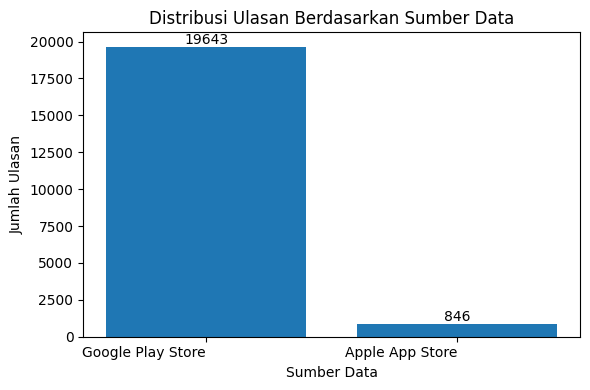

In [ ]:
import matplotlib.pyplot as plt

# 1. Bersihkan kolom sumber dari karakter aneh
df['sumber'] = (
    df['sumber']
    .astype(str)
    .str.replace(';', '', regex=False)
    .str.replace('"', '', regex=False)
    .str.strip()
)

# 2. Standarisasi label sumber
df['sumber_label'] = df['sumber'].map({
    'ulasan_plnmobile_googleplaystore.csv': 'Google Play Store',
    'ulasan_plnmobile_applestore.csv': 'Apple App Store'
})

# 3. BUANG baris yang sumber_label masih NaN
df_plot = df[df['sumber_label'].notna()]

# 4. Hitung jumlah ulasan per sumber
sumber_counts = df_plot['sumber_label'].value_counts()

# 5. Visualisasi
plt.figure(figsize=(6, 4))
bars = plt.bar(sumber_counts.index, sumber_counts.values)

plt.title("Distribusi Ulasan Berdasarkan Sumber Data")
plt.xlabel("Sumber Data")
plt.ylabel("Jumlah Ulasan")

plt.xticks(rotation=0, ha='right')

# 6. Tambahkan angka di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()


# Statistik Kolom Numerik (Rating)

In [ ]:
print("\n STATISTIK KOLOM NUMERIK (RATING)")
print(df['rating'].describe())


 STATISTIK KOLOM NUMERIK (RATING)
count    20489.000000
mean         4.869345
std          0.673421
min          1.000000
25%          5.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: rating, dtype: float64


# Statistik Kolom Kategorikal

In [ ]:
print("\n STATISTIK KOLOM KATEGORIKAL")

kolom_kategorikal = ['sumber']

for kolom in kolom_kategorikal:
    print(f"\nKolom: {kolom}")
    print("Jumlah kategori:", df[kolom].nunique())
    print("Distribusi nilai:")
    print(df[kolom].value_counts())



 STATISTIK KOLOM KATEGORIKAL

Kolom: sumber
Jumlah kategori: 2
Distribusi nilai:
sumber
ulasan_plnmobile_googleplaystore.csv    19643
ulasan_plnmobile_applestore.csv           846
Name: count, dtype: int64


# Jumlah Ulasan Berdasarkan Rating


 JUMLAH ULASAN BERDASARKAN RATING
rating
1.0      522
2.0       89
3.0       83
4.0      156
5.0    19639
Name: count, dtype: int64


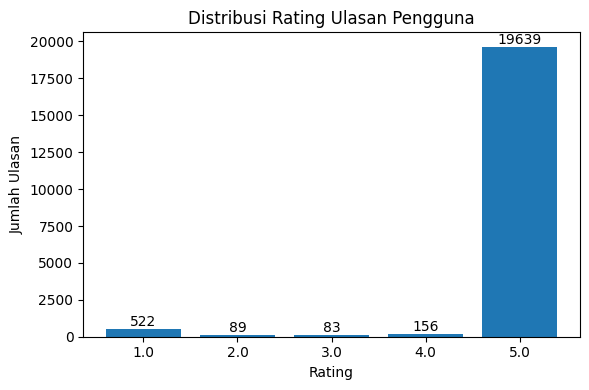

In [ ]:
import matplotlib.pyplot as plt

print("\n JUMLAH ULASAN BERDASARKAN RATING")
rating_counts = df['rating'].value_counts().sort_index()
print(rating_counts)

# Visualisasi
plt.figure(figsize=(6,4))
bars = plt.bar(rating_counts.index.astype(str), rating_counts.values)

plt.title("Distribusi Rating Ulasan Pengguna")
plt.xlabel("Rating")
plt.ylabel("Jumlah Ulasan")

# Tambahkan angka di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()


# Word Cloud


 WORD CLOUD ULASAN PENGGUNA


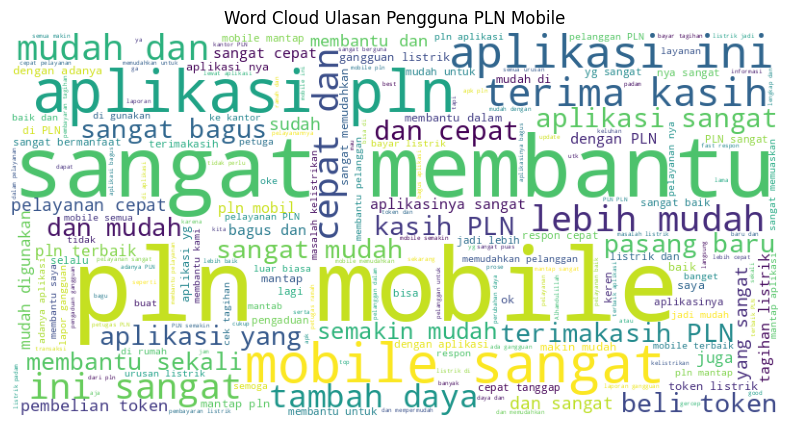

In [ ]:
!pip install wordcloud

from wordcloud import WordCloud

print("\n WORD CLOUD ULASAN PENGGUNA")

text = " ".join(df['ulasan'].dropna().astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=200
).generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Word Cloud Ulasan Pengguna PLN Mobile")
plt.show()